11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.4091 - loss: 1.9938 - val_accuracy: 0.8313 - val_loss: 0.7627
Epoch 2/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8391 - loss: 0.6621 - val_accuracy: 0.8867 - val_loss: 0.4241
Epoch 3/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8830 - loss: 0.4294 - val_accuracy: 0.9031 - val_loss: 0.3473
Epoch 4/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9010 - loss: 0.3547 - val_accuracy: 0.9121 - val_loss: 0.3089
Epoch 5/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9086 - loss: 0.3222 - val_accuracy: 0.9174 - val_loss: 0.2835
Epoch 6/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9147 - loss: 0.2955 - val_accuracy: 0.9235 - val_loss: 0.2662
Epoch 7/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9212 - loss: 0.2772 - val_accuracy: 0.9277 - val_loss: 0.2501
Epoch 8/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9256 - loss: 0.2587 - val_accuracy: 0

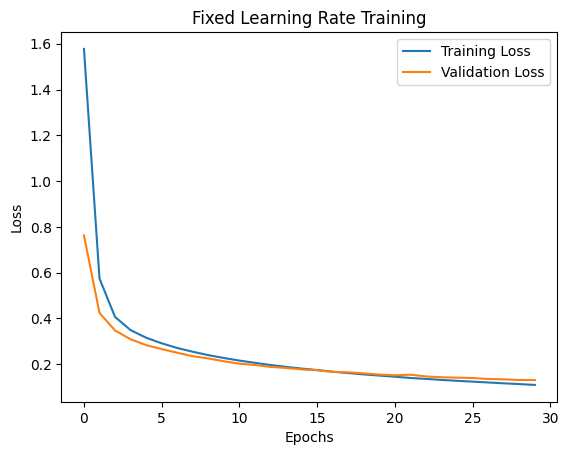

In [1]:
# 1. TRAIN DEEP NEURAL NETWORK MODEL WITH FIXED LEARNING RATE

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

# -----------------------------
# Load MNIST Dataset
# -----------------------------
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalize data
X_train = X_train / 255.0
X_test = X_test / 255.0

# One-hot encode labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# -----------------------------
# Build Deep Neural Network
# -----------------------------
model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

# -----------------------------
# Fixed Learning Rate Optimizer
# -----------------------------
optimizer = tf.keras.optimizers.SGD(learning_rate=0.01)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# -----------------------------
# Train the Model
# -----------------------------
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

# -----------------------------
# Plot Loss Curve
# -----------------------------
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Fixed Learning Rate Training')
plt.show()

Epoch 1/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.3489 - loss: 2.0134 - val_accuracy: 0.8205 - val_loss: 0.7757 - learning_rate: 0.0100
Epoch 2/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8248 - loss: 0.6795 - val_accuracy: 0.8823 - val_loss: 0.4359 - learning_rate: 0.0100
Epoch 3/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8810 - loss: 0.4325 - val_accuracy: 0.9017 - val_loss: 0.3519 - learning_rate: 0.0100
Epoch 4/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8961 - loss: 0.3651 - val_accuracy: 0.9097 - val_loss: 0.3141 - learning_rate: 0.0100
Epoch 5/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9093 - loss: 0.3270 - val_accuracy: 0.9180 - val_loss: 0.2866 - learning_rate: 0.0100
Epoch 6/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9162 - loss: 0.2945 - val_accuracy: 0.9208 - val_loss: 0.2692 - learning_rate: 0.0100
Epoch 7/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9210 - loss: 0.2759 - 

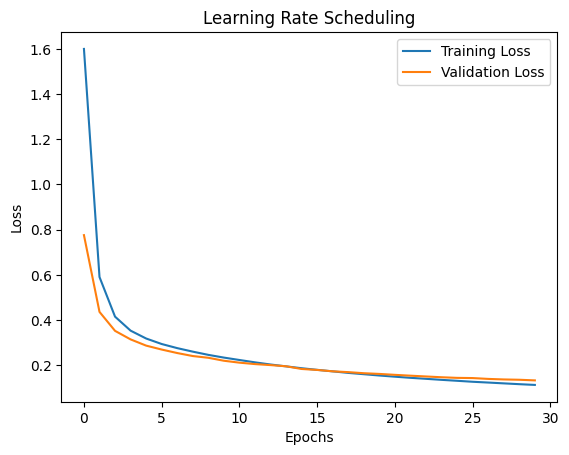

In [2]:
# 2. APPLY LEARNING RATE DECAY STRATEGIES

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ReduceLROnPlateau

# -----------------------------
# Load MNIST Dataset
# -----------------------------
(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# -----------------------------
# Build Deep Neural Network
# -----------------------------
model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

# -----------------------------
# Optimizer with Initial LR
# -----------------------------
optimizer = tf.keras.optimizers.SGD(learning_rate=0.01)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# -----------------------------
# Learning Rate Scheduler
# -----------------------------
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1
)

# -----------------------------
# Train the Model
# -----------------------------
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=128,
    validation_split=0.2,
    callbacks=[lr_scheduler],
    verbose=1
)

# -----------------------------
# Plot Loss Curve
# -----------------------------
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Learning Rate Scheduling')
plt.show()

Epoch 1/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.3855 - loss: 1.9556 - val_accuracy: 0.8332 - val_loss: 0.7401 - learning_rate: 0.0100
Epoch 2/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8350 - loss: 0.6524 - val_accuracy: 0.8862 - val_loss: 0.4226 - learning_rate: 0.0100
Epoch 3/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8783 - loss: 0.4361 - val_accuracy: 0.9023 - val_loss: 0.3451 - learning_rate: 0.0100
Epoch 4/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8945 - loss: 0.3642 - val_accuracy: 0.9113 - val_loss: 0.3055 - learning_rate: 0.0100
Epoch 5/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9083 - loss: 0.3214 - val_accuracy: 0.9190 - val_loss: 0.2831 - learning_rate: 0.0100
Epoch 6/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9162 - loss: 0.2927 - val_accuracy: 0.9238 - val_loss: 0.2641 - learning_rate: 0.0100
Epoch 7/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9181 - loss: 0.2838 - 

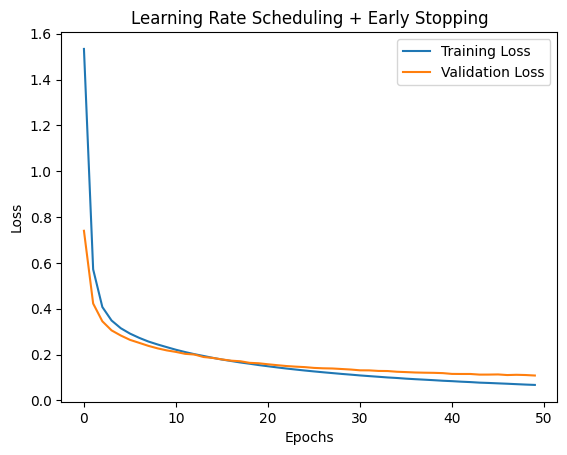

In [3]:
# 3. ENABLE EARLY STOPPING

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# -----------------------------
# Load MNIST Dataset
# -----------------------------
(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# -----------------------------
# Build Deep Neural Network
# -----------------------------
model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

# -----------------------------
# Optimizer
# -----------------------------
optimizer = tf.keras.optimizers.SGD(learning_rate=0.01)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# -----------------------------
# Callbacks
# -----------------------------
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# -----------------------------
# Train Model
# -----------------------------
history = model.fit(
    X_train, y_train,
    epochs=50,  # large number, early stopping will stop it
    batch_size=128,
    validation_split=0.2,
    callbacks=[lr_scheduler, early_stopping],
    verbose=1
)

# -----------------------------
# Plot Loss Curve
# -----------------------------
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Learning Rate Scheduling + Early Stopping')
plt.show()